# Analysis — NLP small-resource experiments

This notebook analyses the results of the three-dataset low-resource NLP project.

Datasets:
- AGNews
- DBpedia
- IMDb50k

The notebook is deliberately separate from `join_results.ipynb`:
- `join_results.ipynb` assembles and checks the global results;
- `analysis.ipynb` focuses on comparisons, visualisations and conclusions.

The main comparisons are made **within each dataset and training-set size**.
No raw average of the three datasets is used.

## Imports and configuration

The notebook is designed to be placed directly in the `nlpsmall` directory:

```text
nlpsmall/
├── analysis.ipynb
├── AGNews/
├── DBpedia/
└── IMDb50k/
```

Only source result files are loaded. Derived files such as
`results_embeddings_comparison.csv` are explicitly excluded because
they would duplicate V6/V7 experiments.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path(".")

DATASETS = {
    "AGNews": ROOT / "AGNews",
    "DBpedia": ROOT / "DBpedia",
    "IMDb": ROOT / "IMDb50k",
}

TRAIN_SIZES = [50, 200, 500, 2000, 10000]

CLASSICAL_EXPERIMENTS = ["Baseline", "V1", "V2", "V3", "V4", "V5"]
SENTENCE_EXPERIMENTS = ["V6.1", "V6.2", "V6.3"]
WORD_EXPERIMENTS = ["V7.1", "V7.2"]

EMBEDDING_EXPERIMENTS = SENTENCE_EXPERIMENTS + WORD_EXPERIMENTS

EXPERIMENT_ORDER = (
    CLASSICAL_EXPERIMENTS
    + SENTENCE_EXPERIMENTS
    + WORD_EXPERIMENTS
)

REPRESENTATION_ORDER = [
    "Count",
    "TF-IDF",
    "Sentence Embeddings",
    "Word Embeddings",
]

# Visual identity
# Family colors are used whenever the 3 representation families are compared
FAMILY_COLORS = [
    "#FE895E",  # Best Classical
    "#CD6889",  # Best Sentence Embedding
    "#96527A",  # Best Word Embedding
]

# Embedding color map is used when individual V6/V7 experiments are compared
EMBEDDING_COLOR_MAP = {
    experiment: color
    for experiment, color in zip(
        EMBEDDING_EXPERIMENTS,
        plt.cm.managua(np.linspace(0.15, 0.85, len(EMBEDDING_EXPERIMENTS)))
    )
}

## Loading the result files

`results_embeddings_comparison.csv` is excluded because derived from  
the V6/V7 result files it would duplicate those experiments.

The loader also handles the three dataset-specific baseline filenames.

In [ ]:
EXCLUDED_FILES = {"results_embeddings_comparison.csv"}


def load_all_results(dataset_paths):
    results = []

    for dataset, folder in dataset_paths.items():

        if not folder.exists():
            raise FileNotFoundError(
                f"Dataset directory not found: {folder}"
            )

        files = sorted(
            file for file in folder.glob("results_*.csv")
            if file.name not in EXCLUDED_FILES
        )

        print(f"{dataset}: {len(files)} source result files")

        for file in files:
            dataframe = pd.read_csv(file)

            dataframe["Dataset"] = dataset
            dataframe["Source file"] = file.name

            results.append(dataframe)

    if not results:
        raise ValueError("No result CSV files were found")

    return pd.concat(results, ignore_index=True)


df_raw = load_all_results(DATASETS)

print()
print("Raw shape:", df_raw.shape)

AGNews: 11 source result files
DBpedia: 11 source result files
IMDb: 11 source result files

Raw shape: (1780, 26)


In [3]:
print("Files loaded by dataset:")

for dataset in DATASETS:
    subset = df_raw[df_raw["Dataset"] == dataset]
    print(f"\n{dataset}")
    print(
        subset["Source file"]
        .value_counts()
        .sort_index()
        .to_string()
    )

Files loaded by dataset:

AGNews
Source file
results_V1.csv                  40
results_V2.csv                  60
results_V3.csv                 135
results_V4.csv                 225
results_V5.csv                  40
results_V6_1_embeddings.csv      5
results_V6_2_embeddings.csv      5
results_V6_3_embeddings.csv      5
results_V7_1_embeddings.csv      5
results_V7_2_embeddings.csv      5
results_baseline.csv            20

DBpedia
Source file
results_DBpedia_baseline.csv     20
results_V1.csv                   40
results_V2.csv                   60
results_V3.csv                  150
results_V4.csv                  255
results_V5.csv                   40
results_V6_1_embeddings.csv       5
results_V6_2_embeddings.csv       5
results_V6_3_embeddings.csv       5
results_V7_1_embeddings.csv       5
results_V7_2_embeddings.csv       5

IMDb
Source file
results_IMDb_baseline.csv       20
results_V1.csv                  40
results_V2.csv                  70
results_V3.csv                

## Harmonising

The source files do not all use the same exact baseline filename convention,
so baseline experiments are normalised here.

`Representation` is the fundamental representation family:
- Count
- TF-IDF
- Sentence Embeddings
- Word Embeddings

`Representation details` describes the concrete representation or model.

In [ ]:
df_global = df_raw.copy()


#
# Experiment names
#

baseline_mask = df_global["Source file"].str.contains(
    "_baseline", case=False, na=False,
)

df_global.loc[baseline_mask, "Experiment"] = "Baseline"


#
# Fundamental representation
#

df_global["Representation"] = df_global["Base Vectorizer"]

df_global.loc[
    df_global["Vectorizer"] == "CountVectorizer",
    "Representation",
] = "Count"

df_global.loc[
    df_global["Vectorizer"] == "TfidfVectorizer",
    "Representation",
] = "TF-IDF"

df_global.loc[
    df_global["Experiment"].isin(SENTENCE_EXPERIMENTS),
    "Representation",
] = "Sentence Embeddings"

df_global.loc[
    df_global["Experiment"].isin(WORD_EXPERIMENTS),
    "Representation",
] = "Word Embeddings"


#
# Representation details
#

df_global["Representation details"] = df_global["Vectorizer"]

df_global.loc[
    df_global["Experiment"].isin(SENTENCE_EXPERIMENTS),
    "Representation details",
] = "all-MiniLM-L6-v2"

df_global.loc[
    df_global["Experiment"].isin(WORD_EXPERIMENTS),
    "Representation details",
] = "GloVe 100d"

df_global.loc[
    df_global["Representation details"] == "CountVectorizer",
    "Representation details",
] = "Count"

df_global.loc[
    df_global["Representation details"] == "TfidfVectorizer",
    "Representation details",
] = "TF-IDF"


#
# Baseline variant
#

df_global.loc[
    df_global["Experiment"] == "Baseline", "Variant"] = "Baseline"


#
# Analysis columns kept
#

global_columns = [
    "Dataset",
    "Experiment",
    "Train size",
    "Representation",
    "Representation details",
    "Preprocessor",
    "Variant",
    "Normalization",
    "Classifier",
    "Accuracy",
    "Macro F1",
    "Train time (s)",
    "Inference time (s)",
]

df_global = df_global[global_columns].copy()

print("Analysis table shape:", df_global.shape)

Analysis table shape: (1780, 13)


## Data quality checks

In [5]:
required_columns = [
    "Dataset",
    "Experiment",
    "Train size",
    "Representation",
    "Macro F1",
    "Accuracy",
]

missing_required = [
    column for column in required_columns
    if column not in df_global.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Datasets:")
print(df_global["Dataset"].value_counts().sort_index())

print()
print("Experiments:")
print(
    df_global["Experiment"]
    .value_counts(dropna=False)
    .reindex(EXPERIMENT_ORDER)
)

print()
print("Training sizes:")
print(sorted(df_global["Train size"].dropna().unique()))

print()
print("Missing values in key analysis columns:")
print(
    df_global[
        ["Dataset", "Experiment", "Train size",
         "Representation", "Macro F1", "Accuracy"]
    ]
    .isna()
    .sum()
)

Datasets:
Dataset
AGNews     545
DBpedia    590
IMDb       645
Name: count, dtype: int64

Experiments:
Experiment
Baseline     60
V1          120
V2          190
V3          465
V4          750
V5          120
V6.1         15
V6.2         15
V6.3         15
V7.1         15
V7.2         15
Name: count, dtype: int64

Training sizes:
[np.int64(50), np.int64(200), np.int64(500), np.int64(2000), np.int64(10000)]

Missing values in key analysis columns:
Dataset           0
Experiment        0
Train size        0
Representation    0
Macro F1          0
Accuracy          0
dtype: int64


In [6]:
print("Observed experiment counts:")

observed_counts = (
    df_global
    .groupby(["Dataset", "Experiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=DATASETS.keys(),
        columns=EXPERIMENT_ORDER,
        fill_value=0,
    )
)
display(observed_counts)

print()
print("Observed training-size counts by dataset and experiment:")

observed_sizes = (
    df_global
    .groupby(["Dataset", "Experiment", "Train size"])
    .size()
    .reset_index(name="n")
)
display(observed_sizes)

Observed experiment counts:


Experiment,Baseline,V1,V2,V3,V4,V5,V6.1,V6.2,V6.3,V7.1,V7.2
Dataset,,,,,,,,,,,
AGNews,20,40,60,135,225,40,5,5,5,5,5
DBpedia,20,40,60,150,255,40,5,5,5,5,5
IMDb,20,40,70,180,270,40,5,5,5,5,5



Observed training-size counts by dataset and experiment:


,Dataset,Experiment,Train size,n
0,AGNews,Baseline,50,4
1,AGNews,Baseline,200,4
2,AGNews,Baseline,500,4
3,AGNews,Baseline,2000,4
4,AGNews,Baseline,10000,4
...,...,...,...,...
160,IMDb,V7.2,50,1
161,IMDb,V7.2,200,1
162,IMDb,V7.2,500,1
163,IMDb,V7.2,2000,1


### Experiment counts

Compact structural check of the loaded source files.


In [7]:
display(observed_counts)

Experiment,Baseline,V1,V2,V3,V4,V5,V6.1,V6.2,V6.3,V7.1,V7.2
Dataset,,,,,,,,,,,
AGNews,20,40,60,135,225,40,5,5,5,5,5
DBpedia,20,40,60,150,255,40,5,5,5,5,5
IMDb,20,40,70,180,270,40,5,5,5,5,5


### Training-size coverage


In [8]:
display(observed_sizes)

,Dataset,Experiment,Train size,n
0,AGNews,Baseline,50,4
1,AGNews,Baseline,200,4
2,AGNews,Baseline,500,4
3,AGNews,Baseline,2000,4
4,AGNews,Baseline,10000,4
...,...,...,...,...
160,IMDb,V7.2,50,1
161,IMDb,V7.2,200,1
162,IMDb,V7.2,500,1
163,IMDb,V7.2,2000,1


### Structural checks

In [9]:
expected_sizes = set(TRAIN_SIZES)
missing_sizes = []

for dataset in DATASETS:
    for experiment in EXPERIMENT_ORDER:
        observed = set(
            observed_sizes.loc[
                (observed_sizes["Dataset"] == dataset)
                & (observed_sizes["Experiment"] == experiment),
                "Train size",
            ]
        )

        missing = expected_sizes - observed
        if missing:
            missing_sizes.append(
                {
                    "Dataset": dataset,
                    "Experiment": experiment,
                    "Missing train sizes": sorted(missing),
                }
            )

if missing_sizes:
    print("WARNING: missing training sizes:")
    display(pd.DataFrame(missing_sizes))

else:
    print("Training-size coverage check: OK")

Training-size coverage check: OK


## Analytical subsets

The original `df_global` remains the source table.

In [10]:
df_classical = df_global[
    df_global["Experiment"].isin(CLASSICAL_EXPERIMENTS)
].copy()

df_sentence = df_global[
    df_global["Experiment"].isin(SENTENCE_EXPERIMENTS)
].copy()

df_word = df_global[
    df_global["Experiment"].isin(WORD_EXPERIMENTS)
].copy()

df_embeddings = df_global[
    df_global["Experiment"].isin(EMBEDDING_EXPERIMENTS)
].copy()

print("Classical:", df_classical.shape)
print("Sentence embeddings:", df_sentence.shape)
print("Word embeddings:", df_word.shape)
print("All embeddings:", df_embeddings.shape)

Classical: (1705, 13)
Sentence embeddings: (45, 13)
Word embeddings: (30, 13)
All embeddings: (75, 13)


## Best result within each dataset and training size

Global performance reference.

If several experiments have exactly the same best Macro F1, all tied rows
are retained.

In [11]:
best_f1 = (
    df_global
    .groupby(["Dataset", "Train size"])["Macro F1"]
    .transform("max")
)

df_best_all = (
    df_global[df_global["Macro F1"] == best_f1]
    [
        [
            "Dataset",
            "Train size",
            "Experiment",
            "Representation",
            "Representation details",
            "Preprocessor",
            "Variant",
            "Classifier",
            "Macro F1",
            "Accuracy",
        ]
    ]
    .sort_values(
        ["Dataset", "Train size", "Macro F1", "Experiment"],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

display(
    df_best_all.style.format({"Macro F1": "{:.4f}", "Accuracy": "{:.4f}"})
)

,Dataset,Train size,Experiment,Representation,Representation details,Preprocessor,Variant,Classifier,Macro F1,Accuracy
0,AGNews,50,V6.3,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,Nearest Centroid,0.8068,0.8063
1,AGNews,200,V6.3,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,Nearest Centroid,0.8492,0.8492
2,AGNews,500,V6.3,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,Nearest Centroid,0.8554,0.8557
3,AGNews,2000,V6.1,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,LinearSVC,0.8729,0.8730
4,AGNews,2000,V6.2,Sentence Embeddings,all-MiniLM-L6-v2,nan,L2,LinearSVC,0.8729,0.8730
5,AGNews,10000,V5,TF-IDF,TF-IDF + StopWords + Bigrams,nan,GridSearchCV,MultinomialNB,0.9020,0.9022
6,DBpedia,50,V7.1,Word Embeddings,GloVe 100d,nan,Mean Pooling,LinearSVC,0.7808,0.7913
7,DBpedia,200,V6.3,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,Nearest Centroid,0.8919,0.8931
8,DBpedia,500,V6.1,Sentence Embeddings,all-MiniLM-L6-v2,nan,Raw,LinearSVC,0.9205,0.9219
9,DBpedia,500,V6.2,Sentence Embeddings,all-MiniLM-L6-v2,nan,L2,LinearSVC,0.9205,0.9219


## Best classical, sentence-embedding and word-embedding results

The three families are compared **inside each dataset and training size**.

In [12]:
def best_by_group(dataframe, group_name):
    maxima = (
        dataframe
        .groupby(["Dataset", "Train size"])["Macro F1"]
        .transform("max")
    )
    result = (
        dataframe[dataframe["Macro F1"] == maxima]
        .copy()
        .sort_values(
            ["Dataset", "Train size", "Experiment", "Macro F1"],
            ascending=[True, True, True, False],
        )
    )
    result["Family"] = group_name

    return result


df_best_classical = best_by_group(df_classical, "Best Classical")
df_best_sentence = best_by_group(df_sentence, "Best Sentence Embedding")
df_best_word = best_by_group(df_word, "Best Word Embedding")

display(
    df_best_classical[
        ["Dataset", "Train size", "Experiment", "Macro F1", "Accuracy"]
    ].style.format({"Macro F1": "{:.4f}", "Accuracy": "{:.4f}"})
)

display(
    df_best_sentence[
        ["Dataset", "Train size", "Experiment", "Macro F1", "Accuracy"]
    ].style.format({"Macro F1": "{:.4f}", "Accuracy": "{:.4f}"})
)

display(
    df_best_word[
        ["Dataset", "Train size", "Experiment", "Macro F1", "Accuracy"]
    ].style.format({"Macro F1": "{:.4f}", "Accuracy": "{:.4f}"})
)

,Dataset,Train size,Experiment,Macro F1,Accuracy
123,AGNews,50,V3,0.6083,0.6113
475,AGNews,200,V5,0.7528,0.7530
483,AGNews,500,V5,0.8149,0.8150
81,AGNews,2000,V2,0.8713,0.8720
187,AGNews,2000,V3,0.8713,0.8720
403,AGNews,2000,V4,0.8713,0.8720
488,AGNews,2000,V5,0.8713,0.8720
489,AGNews,2000,V5,0.8713,0.8720
497,AGNews,10000,V5,0.9020,0.9022
676,DBpedia,50,V3,0.7045,0.7194


,Dataset,Train size,Experiment,Macro F1,Accuracy
510,AGNews,50,V6.3,0.8068,0.8063
511,AGNews,200,V6.3,0.8492,0.8492
512,AGNews,500,V6.3,0.8554,0.8557
503,AGNews,2000,V6.1,0.8729,0.8730
508,AGNews,2000,V6.2,0.8729,0.8730
504,AGNews,10000,V6.1,0.8891,0.8892
509,AGNews,10000,V6.2,0.8891,0.8892
1110,DBpedia,50,V6.1,0.7421,0.7509
1115,DBpedia,50,V6.2,0.7421,0.7509
1121,DBpedia,200,V6.3,0.8919,0.8931


,Dataset,Train size,Experiment,Macro F1,Accuracy
515,AGNews,50,V7.1,0.8036,0.8037
516,AGNews,200,V7.1,0.8392,0.8389
517,AGNews,500,V7.1,0.8520,0.8521
518,AGNews,2000,V7.1,0.8708,0.8709
519,AGNews,10000,V7.1,0.8843,0.8845
1125,DBpedia,50,V7.1,0.7808,0.7913
1126,DBpedia,200,V7.1,0.8806,0.8814
1127,DBpedia,500,V7.1,0.9038,0.9045
1128,DBpedia,2000,V7.1,0.9250,0.9252
1129,DBpedia,10000,V7.1,0.9417,0.9419


# Performance analysis

## Family comparison across training sizes (Figure 1)

The curves provide the **evolution view** for each dataset and show how the best
Macro F1 changes within each representation family as the training set grows.

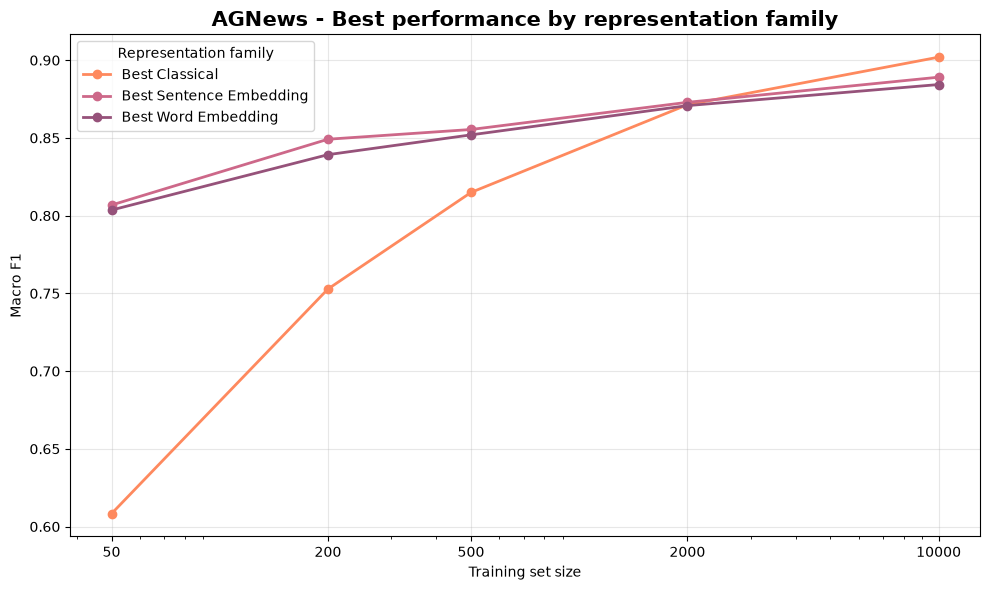

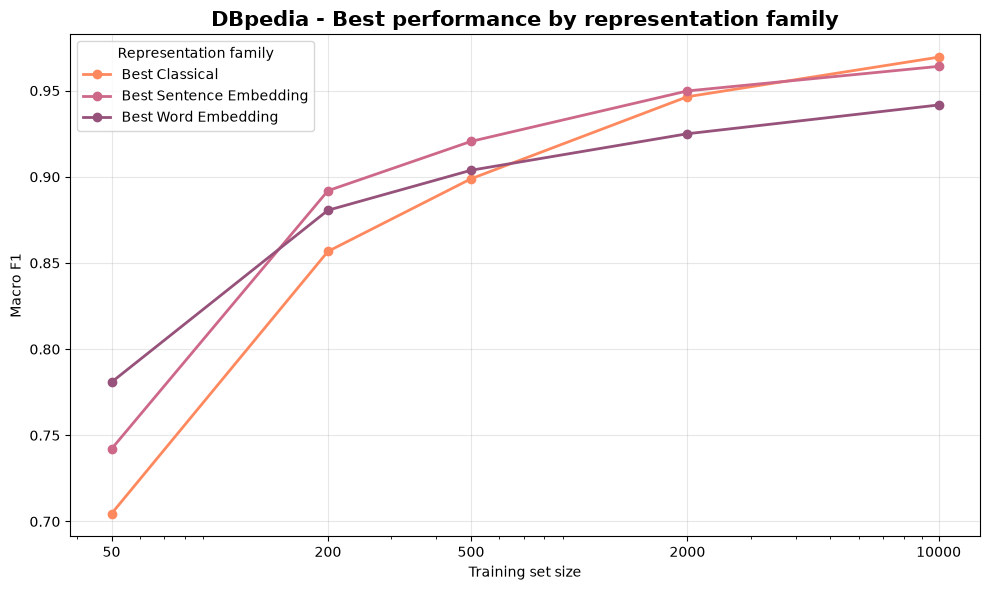

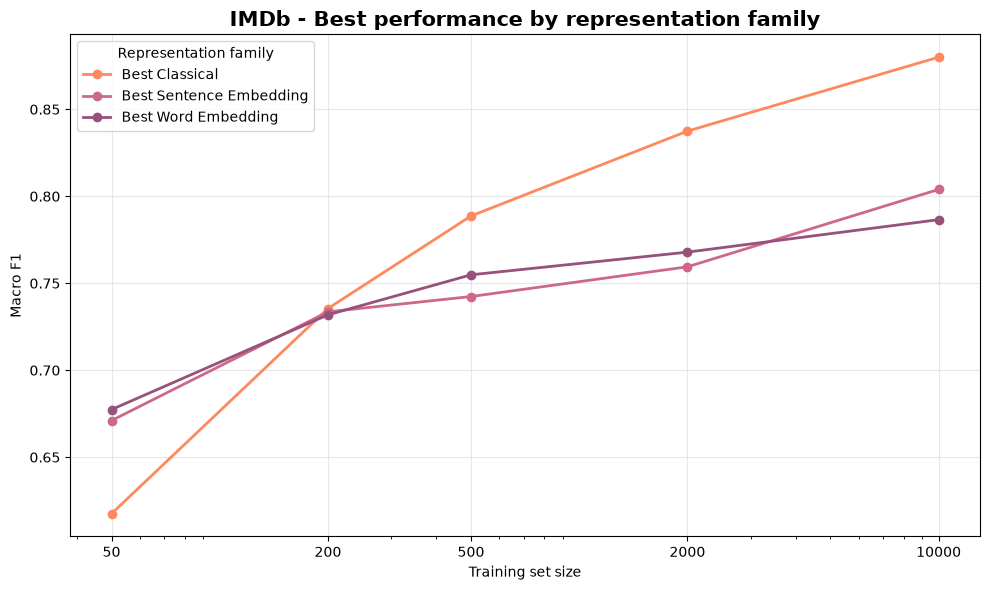

In [13]:
family_tables = []

for dataframe in [
    df_best_classical,
    df_best_sentence,
    df_best_word,
]:
    family_tables.append(
        dataframe[["Dataset", "Train size", "Family", "Macro F1"]].copy()
    )

df_family_best = pd.concat(family_tables, ignore_index=True)

# If a family contains a tie, keep one value for the family-level curve
df_family_curve = (
    df_family_best
    .groupby(
        ["Dataset", "Train size", "Family"], as_index=False)["Macro F1"]
    .max()
)

FAMILY_ORDER = [
    "Best Classical",
    "Best Sentence Embedding",
    "Best Word Embedding",
]

for dataset in DATASETS:
    subset = df_family_curve[
        df_family_curve["Dataset"] == dataset
    ]

    fig, ax = plt.subplots(figsize=(10, 6))

    for position, family in enumerate(FAMILY_ORDER):
        curve = (
            subset[subset["Family"] == family]
            .sort_values("Train size")
        )

        if curve.empty:
            continue

        ax.plot(
            curve["Train size"].to_numpy(),
            curve["Macro F1"].to_numpy(),
            marker="o",
            linewidth=2,
            color=FAMILY_COLORS[position],
            label=family,
        )

    ax.set_title(
        f"{dataset} - Best performance by representation family",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")
    ax.set_xscale("log")
    ax.set_xticks(TRAIN_SIZES)
    ax.set_xticklabels(TRAIN_SIZES)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Representation family")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Family comparison by training size (Figure 2)

The bars provide the **direct comparison view**: at each training-set size,
the three representation families can be compared side by side.

In [14]:
# Best Macro F1 for each representation family
# at each dataset and training-set size

classical_curve = (
    df_best_classical
    .groupby(["Dataset", "Train size"], as_index=False)["Macro F1"]
    .max()
    .rename(columns={"Macro F1": "Best Classical F1"})
)

sentence_curve = (
    df_best_sentence
    .groupby(["Dataset", "Train size"], as_index=False)["Macro F1"]
    .max()
    .rename(columns={"Macro F1": "Best Sentence F1"})
)

word_curve = (
    df_best_word
    .groupby(["Dataset", "Train size"], as_index=False)["Macro F1"]
    .max()
    .rename(columns={"Macro F1": "Best Word F1"})
)

df_gain = (
    classical_curve
    .merge(sentence_curve, on=["Dataset", "Train size"], how="left")
    .merge(word_curve, on=["Dataset", "Train size"], how="left")
)

# Although the visualisation uses the absolute Macro F1 values,
# differences are retained for numerical analysis.

df_gain["Sentence gain"] = (
    df_gain["Best Sentence F1"] - df_gain["Best Classical F1"]
)

df_gain["Word gain"] = (
    df_gain["Best Word F1"] - df_gain["Best Classical F1"]
)

display(
    df_gain.style.format({
        "Best Classical F1": "{:.4f}",
        "Best Sentence F1": "{:.4f}",
        "Best Word F1": "{:.4f}",
        "Sentence gain": "{:+.4f}",
        "Word gain": "{:+.4f}",
    })
)

,Dataset,Train size,Best Classical F1,Best Sentence F1,Best Word F1,Sentence gain,Word gain
0,AGNews,50,0.6083,0.8068,0.8036,+0.1985,+0.1953
1,AGNews,200,0.7528,0.8492,0.8392,+0.0964,+0.0864
2,AGNews,500,0.8149,0.8554,0.8520,+0.0405,+0.0370
3,AGNews,2000,0.8713,0.8729,0.8708,+0.0016,-0.0006
4,AGNews,10000,0.9020,0.8891,0.8843,-0.0129,-0.0176
5,DBpedia,50,0.7045,0.7421,0.7808,+0.0376,+0.0763
6,DBpedia,200,0.8567,0.8919,0.8806,+0.0352,+0.0239
7,DBpedia,500,0.8988,0.9205,0.9038,+0.0217,+0.0050
8,DBpedia,2000,0.9465,0.9498,0.9250,+0.0034,-0.0215
9,DBpedia,10000,0.9694,0.9641,0.9417,-0.0053,-0.0277


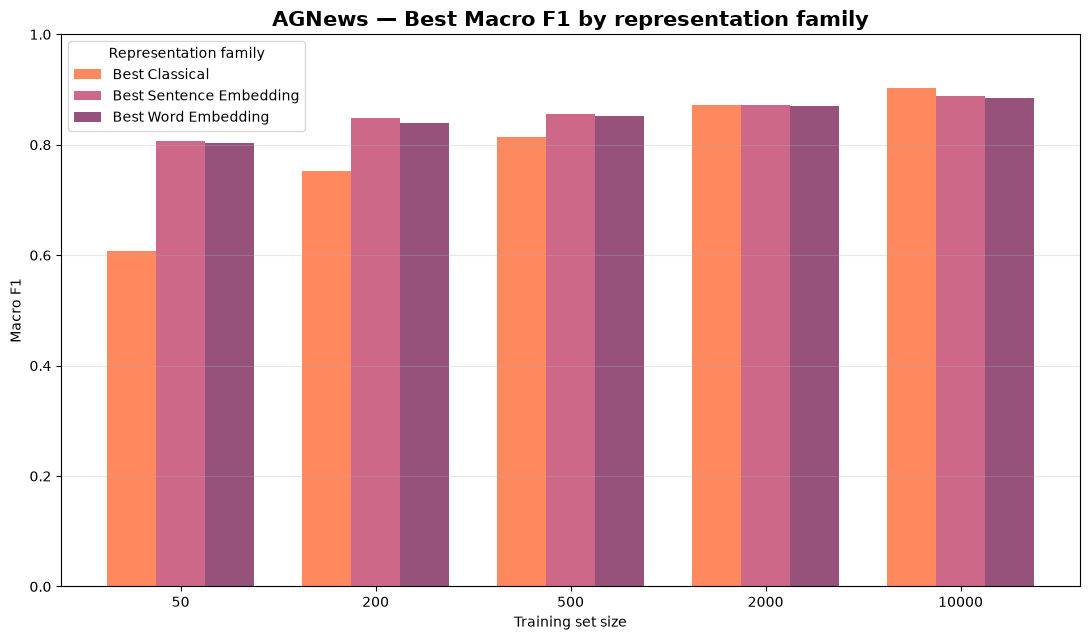

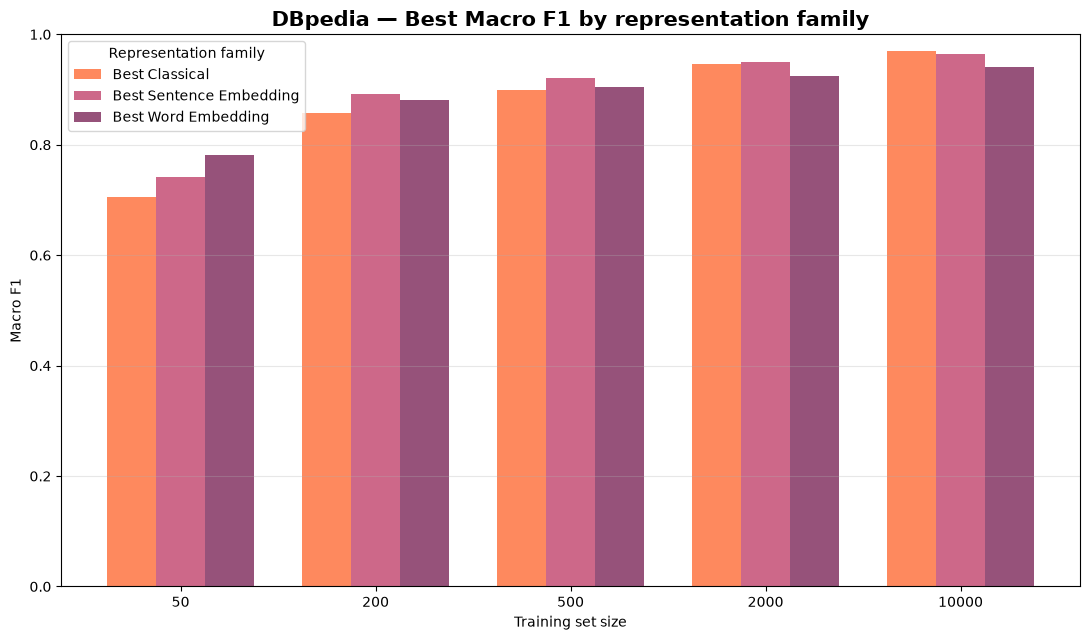

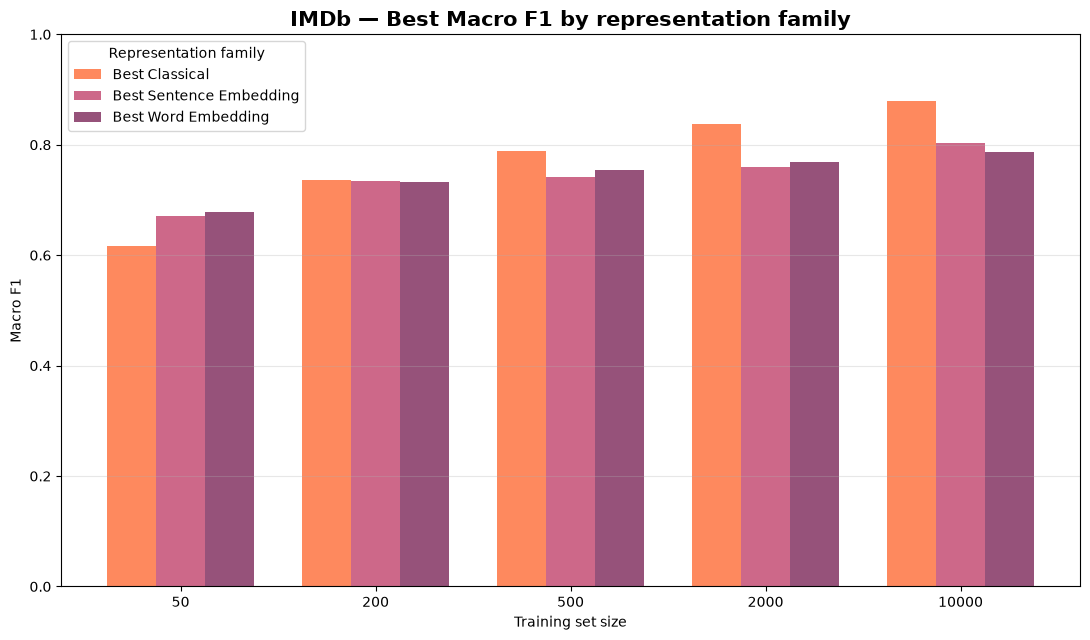

In [15]:
FAMILY_LABELS = [
    "Best Classical",
    "Best Sentence Embedding",
    "Best Word Embedding",
]

FAMILY_COLUMNS = {
    "Best Classical": "Best Classical F1",
    "Best Sentence Embedding": "Best Sentence F1",
    "Best Word Embedding": "Best Word F1",
}

for dataset in DATASETS:

    subset = (
        df_gain[df_gain["Dataset"] == dataset]
        .sort_values("Train size")
        .copy()
    )

    x = np.arange(len(subset))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 6.5))

    for position, family in enumerate(FAMILY_LABELS):

        values = subset[FAMILY_COLUMNS[family]].to_numpy()

        ax.bar(
            x + (position - 1) * width,
            values,
            width=width,
            color=FAMILY_COLORS[position],
            label=family,
        )

    ax.set_title(
        f"{dataset} — Best Macro F1 by representation family",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")

    ax.set_xticks(x)
    ax.set_xticklabels(subset["Train size"].astype(str))

    ax.set_ylim(0.0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Representation family")

    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Detailed comparison of the five embedding experiments (Figure 3)

The experiment colours are defined in the configuration cell and reused
here and in Figures 4 and 5.


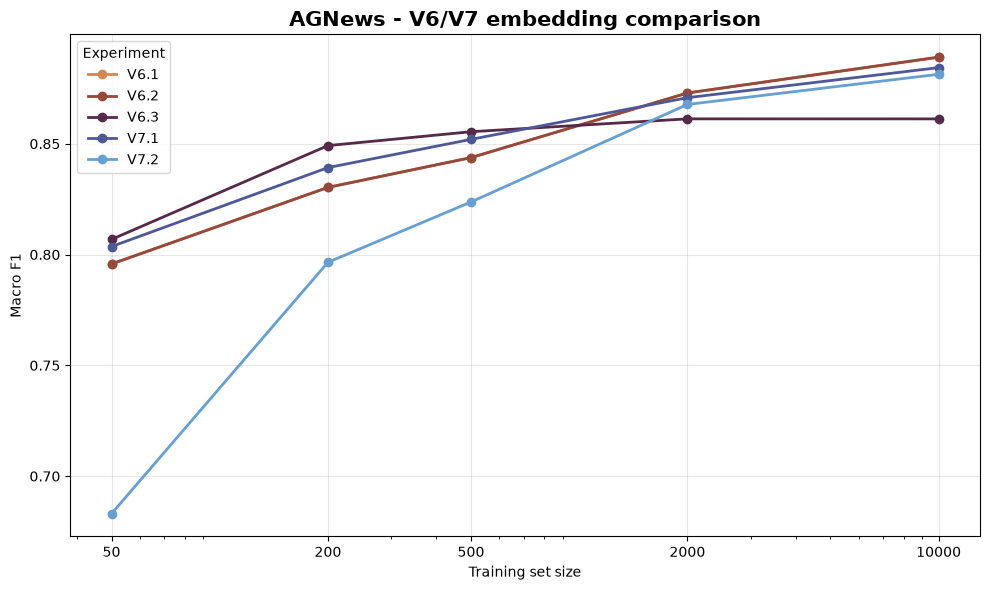

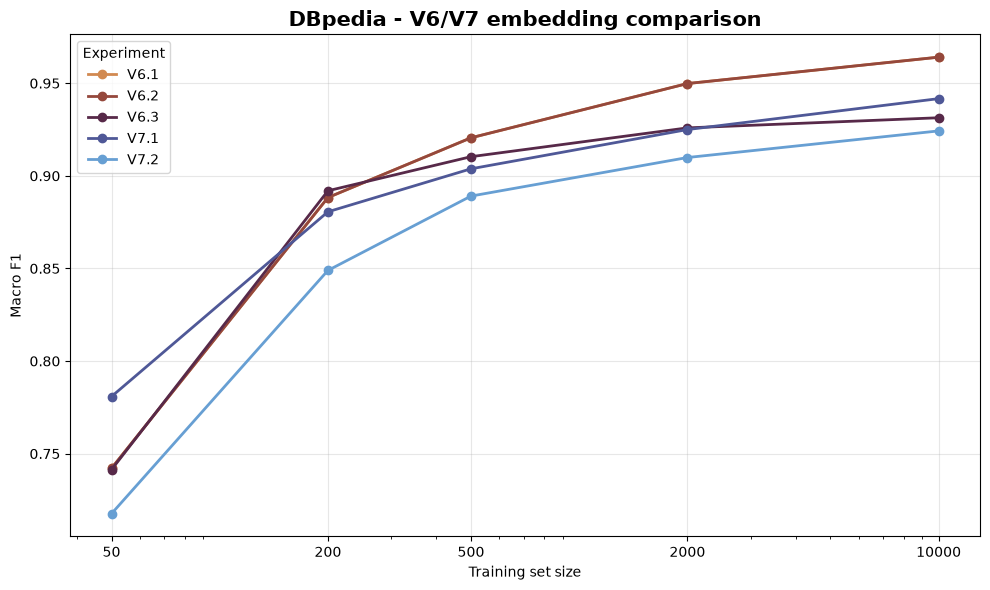

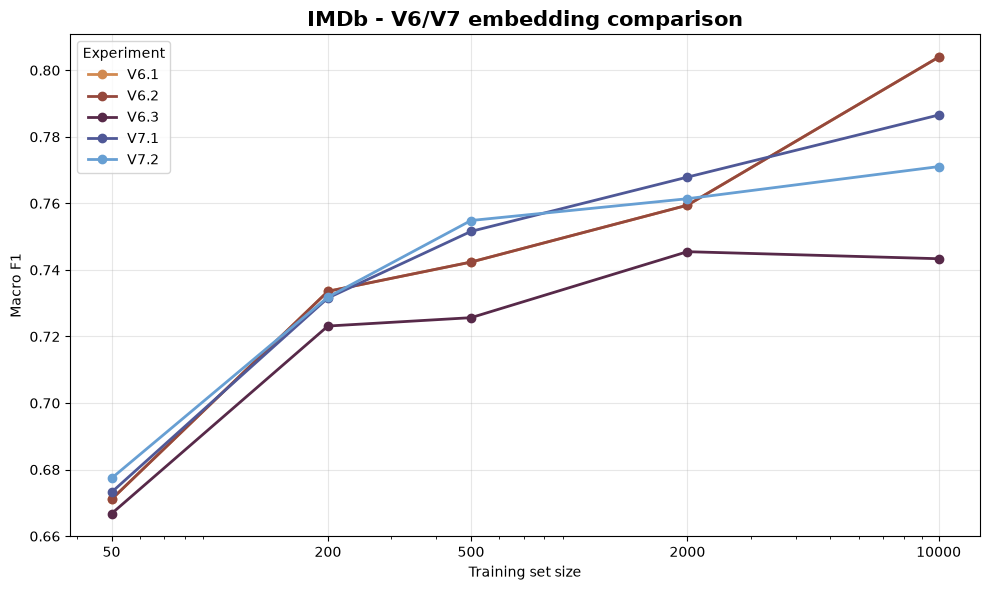

In [16]:
for dataset in DATASETS:
    subset = (
        df_embeddings[df_embeddings["Dataset"] == dataset]
        .sort_values(["Experiment", "Train size"])
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for experiment in EMBEDDING_EXPERIMENTS:
        curve = subset[
            subset["Experiment"] == experiment
        ].sort_values("Train size")

        if curve.empty:
            continue

        ax.plot(
            curve["Train size"].to_numpy(),
            curve["Macro F1"].to_numpy(),
            marker="o",
            linewidth=2,
            color=EMBEDDING_COLOR_MAP[experiment],
            label=experiment,
        )

    ax.set_title(
        f"{dataset} - V6/V7 embedding comparison",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")
    ax.set_xscale("log")
    ax.set_xticks(TRAIN_SIZES)
    ax.set_xticklabels(TRAIN_SIZES)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Experiment")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Sentence-embedding details

Isolation of the sentence-embedding experiments allows to assess whether
normalisation and the centroid classifier materially change the result.


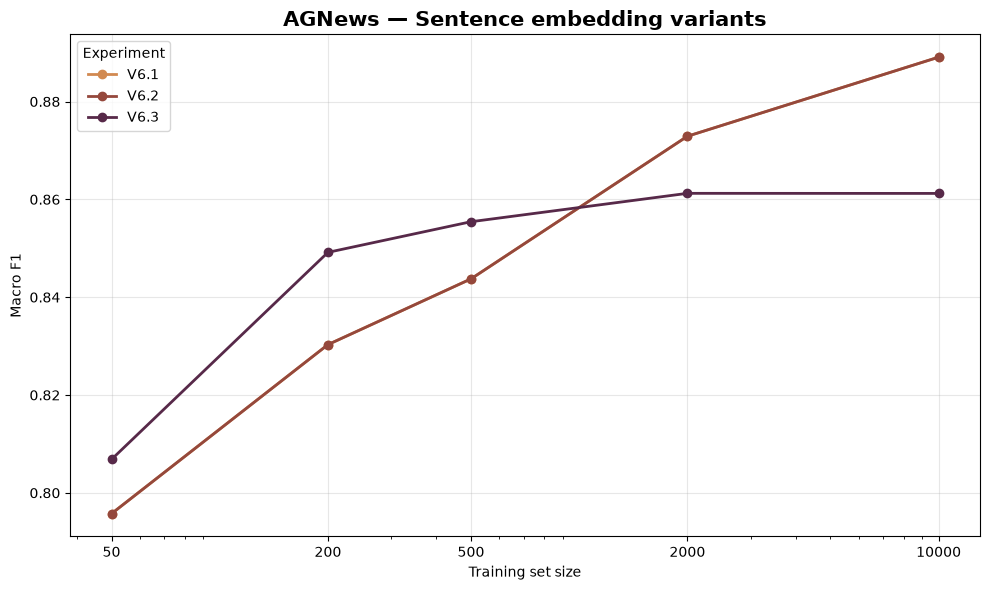

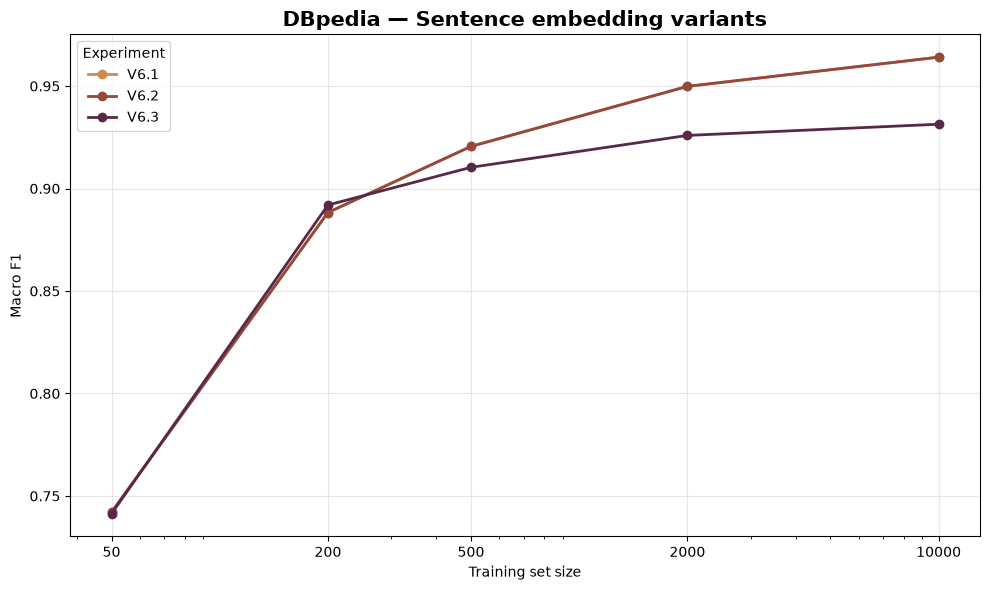

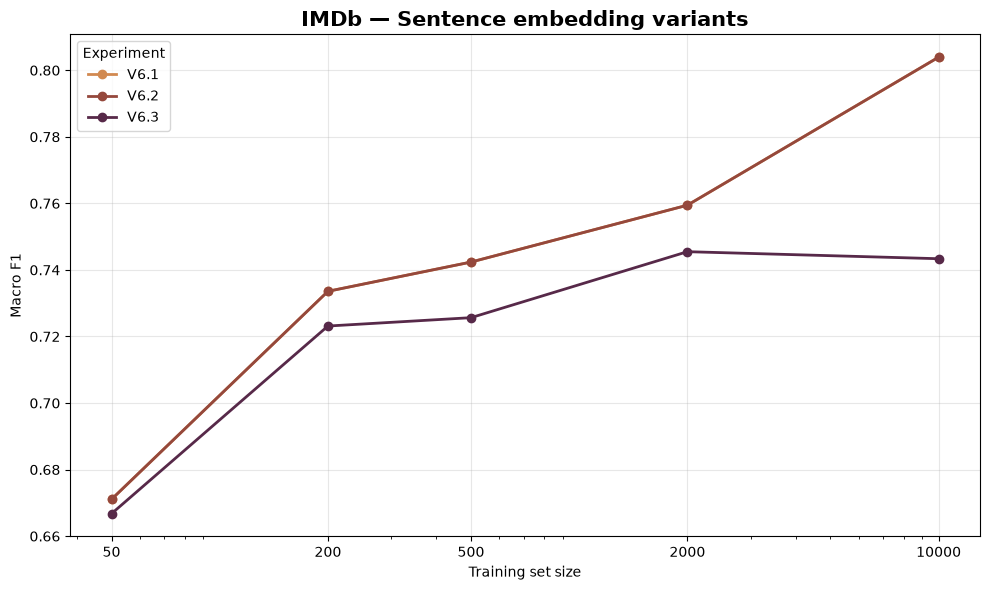

In [17]:
for dataset in DATASETS:
    subset = (
        df_sentence[df_sentence["Dataset"] == dataset]
        .sort_values(["Experiment", "Train size"])
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for experiment in SENTENCE_EXPERIMENTS:
        curve = subset[
            subset["Experiment"] == experiment
        ].sort_values("Train size")

        if curve.empty:
            continue

        ax.plot(
            curve["Train size"].to_numpy(),
            curve["Macro F1"].to_numpy(),
            marker="o",
            linewidth=2,
            color=EMBEDDING_COLOR_MAP[experiment],
            label=experiment,
        )

    ax.set_title(
        f"{dataset} — Sentence embedding variants",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")
    ax.set_xscale("log")
    ax.set_xticks(TRAIN_SIZES)
    ax.set_xticklabels(TRAIN_SIZES)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Experiment")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

V6.1 disappears under the V6.2 lines  

because most of the time the results with or without normalisation are exactly the same.

## Word embeddings (Figure 5)

This isolates the two GloVe 100d pooling strategies:
- V7.1 — Mean Pooling
- V7.2 — TF-IDF Weighted Mean

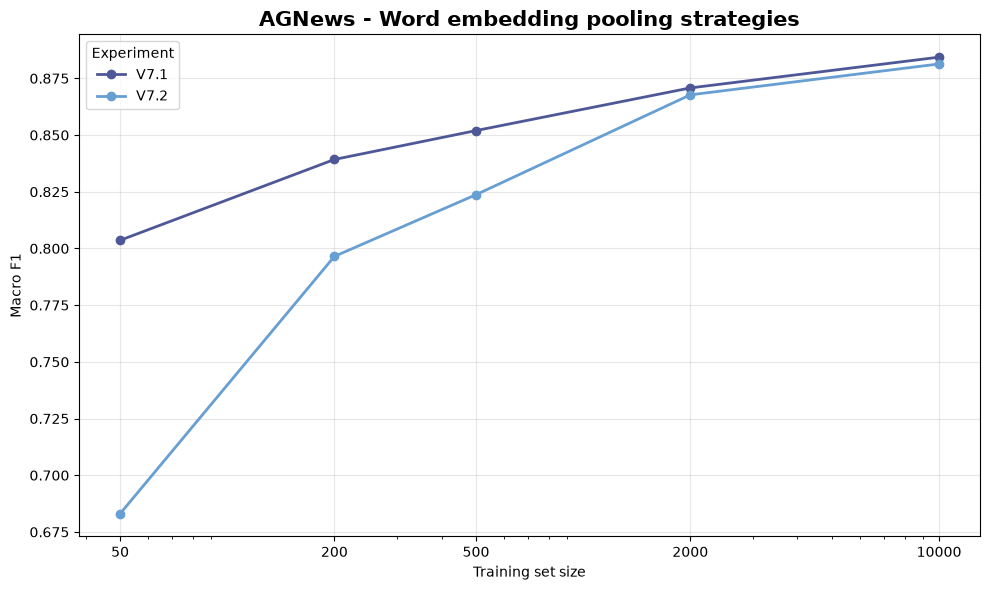

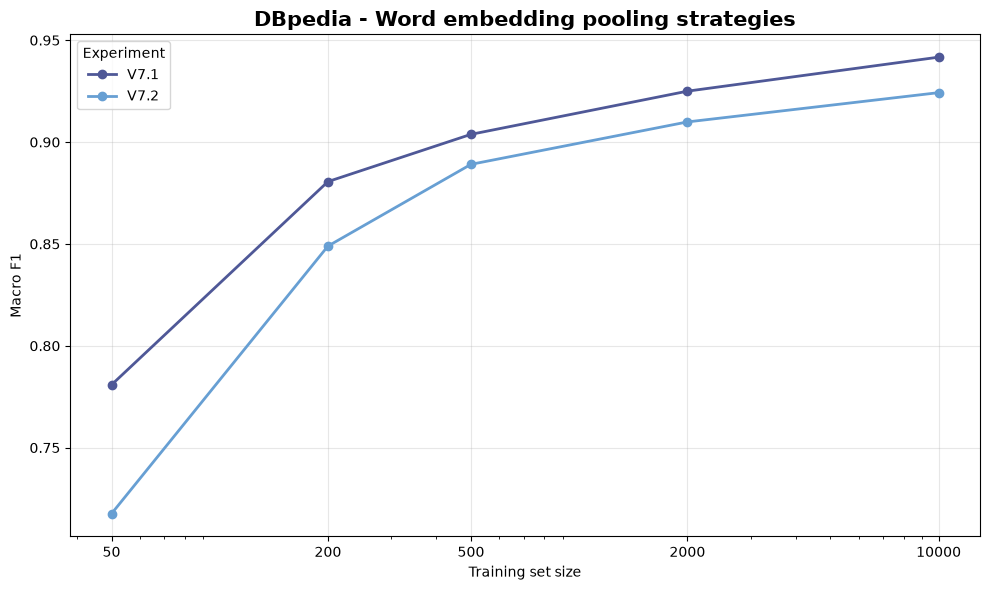

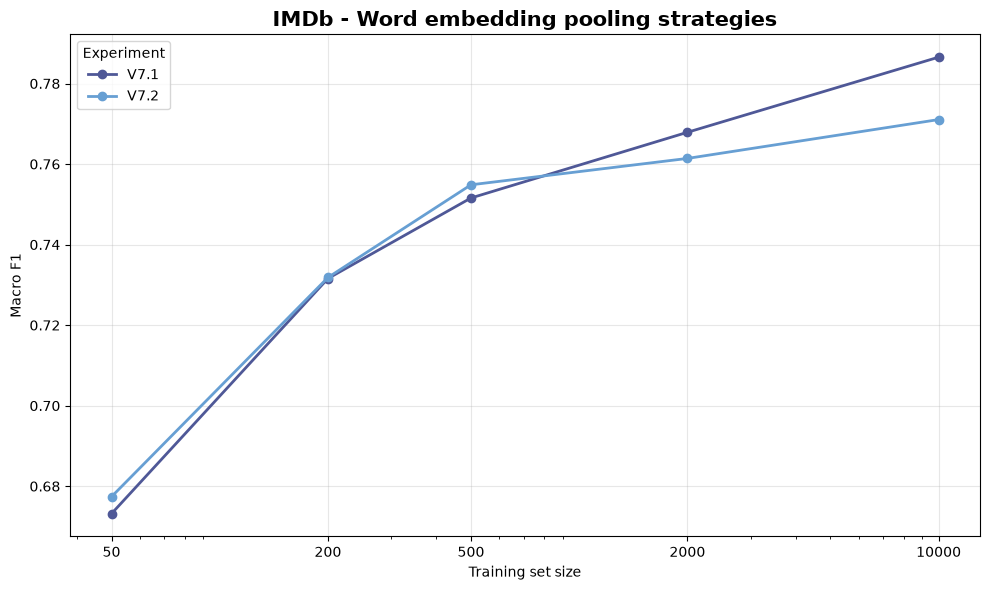

In [18]:
for dataset in DATASETS:

    subset = (
        df_word[df_word["Dataset"] == dataset]
        .sort_values(["Experiment", "Train size"])
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    for experiment in WORD_EXPERIMENTS:

        curve = subset[
            subset["Experiment"] == experiment
        ].sort_values("Train size")

        if curve.empty:
            continue

        ax.plot(
            curve["Train size"].to_numpy(),
            curve["Macro F1"].to_numpy(),
            marker="o",
            linewidth=2,
            color=EMBEDDING_COLOR_MAP[experiment],
            label=experiment,
        )

    ax.set_title(
        f"{dataset} - Word embedding pooling strategies",
        fontsize=15,
        fontweight="bold",
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")
    ax.set_xscale("log")
    ax.set_xticks(TRAIN_SIZES)
    ax.set_xticklabels(TRAIN_SIZES)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Experiment")

    fig.tight_layout()
    plt.show()
    plt.close(fig)

# Ranking and summary tables

## Ranking of experiments within each dataset and training size

The rank is calculated separately for each dataset and training size.
The complete ranking is retained in memory and exported to HTML, while the
notebook displays only the Top 10 rows for readability.


In [19]:
df_ranked = df_global.copy()

df_ranked["Rank"] = (
    df_ranked
    .groupby(["Dataset", "Train size"])["Macro F1"]
    .rank(method="min", ascending=False)
)

df_rank_summary = (
    df_ranked[
        [
            "Dataset",
            "Train size",
            "Rank",
            "Experiment",
            "Representation",
            "Variant",
            "Classifier",
            "Macro F1",
        ]
    ]
    .sort_values(
        ["Dataset", "Train size", "Rank", "Macro F1"],
        ascending=[True, True, True, False],
    )
    .reset_index(drop=True)
)

# Notebook view: only the most useful rows.
df_rank_top10 = df_rank_summary[df_rank_summary["Rank"] <= 10].copy()

display(
    df_rank_top10.style.format({
        "Rank": "{:.0f}",
        "Macro F1": "{:.4f}",
    })
)

# Complete ranking: convenient for later inspection without filling the notebook.
ranking_html = (
    df_rank_summary
    .style
    .format({"Rank": "{:.0f}", "Macro F1": "{:.4f}"})
    .set_caption("Complete experiment ranking by dataset and training-set size")
    .to_html()
)

Path("ranking_full.html").write_text(ranking_html, encoding="utf-8")

# print(f"Complete ranking exported to: {Path('ranking_full.html').resolve()}")
print("Complete ranking exported")


,Dataset,Train size,Rank,Experiment,Representation,Variant,Classifier,Macro F1
0,AGNews,50,1,V6.3,Sentence Embeddings,Raw,Nearest Centroid,0.8068
1,AGNews,50,2,V7.1,Word Embeddings,Mean Pooling,LinearSVC,0.8036
2,AGNews,50,3,V6.1,Sentence Embeddings,Raw,LinearSVC,0.7957
3,AGNews,50,3,V6.2,Sentence Embeddings,L2,LinearSVC,0.7957
4,AGNews,50,5,V7.2,Word Embeddings,TF-IDF Weighted Mean,LinearSVC,0.6831
5,AGNews,50,6,V3,Count,Snowball,MultinomialNB,0.6083
6,AGNews,50,7,V3,Count,Porter,MultinomialNB,0.6079
7,AGNews,50,8,V3,Count,Snowball,MultinomialNB,0.6079
8,AGNews,50,8,V4,Count,Baseline,MultinomialNB,0.6079
9,AGNews,50,8,V5,Count,Default,MultinomialNB,0.6079


Complete ranking exported


## Best method in each family - compact final table

In [20]:
df_family_final = (
    df_family_best
    .pivot_table(
        index=["Dataset", "Train size"],
        columns="Family",
        values="Macro F1",
        aggfunc="max",
    )
    .reset_index()
)

display(
    df_family_final.style.format({
        column: "{:.4f}"
        for column in df_family_final.columns
        if column not in ["Dataset", "Train size"]
    })
)

Family,Dataset,Train size,Best Classical,Best Sentence Embedding,Best Word Embedding
0,AGNews,50,0.6083,0.8068,0.8036
1,AGNews,200,0.7528,0.8492,0.8392
2,AGNews,500,0.8149,0.8554,0.8520
3,AGNews,2000,0.8713,0.8729,0.8708
4,AGNews,10000,0.9020,0.8891,0.8843
5,DBpedia,50,0.7045,0.7421,0.7808
6,DBpedia,200,0.8567,0.8919,0.8806
7,DBpedia,500,0.8988,0.9205,0.9038
8,DBpedia,2000,0.9465,0.9498,0.9250
9,DBpedia,10000,0.9694,0.9641,0.9417


## Best overall method - compact final table

The table keeps the strongest result(s) for each dataset and training-set size.
Exact ties are retained.


In [21]:
best_overall_compact = (
    df_best_all[
        [
            "Dataset",
            "Train size",
            "Experiment",
            "Representation",
            "Variant",
            "Classifier",
            "Macro F1",
            "Accuracy",
        ]
    ]
    .copy()
)

display(
    best_overall_compact.style.format({
        "Macro F1": "{:.4f}",
        "Accuracy": "{:.4f}",
    })
)

,Dataset,Train size,Experiment,Representation,Variant,Classifier,Macro F1,Accuracy
0,AGNews,50,V6.3,Sentence Embeddings,Raw,Nearest Centroid,0.8068,0.8063
1,AGNews,200,V6.3,Sentence Embeddings,Raw,Nearest Centroid,0.8492,0.8492
2,AGNews,500,V6.3,Sentence Embeddings,Raw,Nearest Centroid,0.8554,0.8557
3,AGNews,2000,V6.1,Sentence Embeddings,Raw,LinearSVC,0.8729,0.8730
4,AGNews,2000,V6.2,Sentence Embeddings,L2,LinearSVC,0.8729,0.8730
5,AGNews,10000,V5,TF-IDF,GridSearchCV,MultinomialNB,0.9020,0.9022
6,DBpedia,50,V7.1,Word Embeddings,Mean Pooling,LinearSVC,0.7808,0.7913
7,DBpedia,200,V6.3,Sentence Embeddings,Raw,Nearest Centroid,0.8919,0.8931
8,DBpedia,500,V6.1,Sentence Embeddings,Raw,LinearSVC,0.9205,0.9219
9,DBpedia,500,V6.2,Sentence Embeddings,L2,LinearSVC,0.9205,0.9219


# Key observations

The final observations below are generated directly from the analysed results.
This keeps the written interpretation tied to the current source files rather
than hard-coding conclusions that could become outdated after a rerun.


In [22]:
def describe_direction(value, positive="higher", negative="lower"):
    if value > 0:
        return positive
    if value < 0:
        return negative
    return "unchanged"

#
# 1. Family winners across all dataset/training-size combinations
#

family_long = df_family_best.copy()

family_winners = (
    family_long
    .groupby(["Dataset", "Train size", "Family"])["Macro F1"]
    .max()
    .reset_index()
)

family_wide = (
    family_winners
    .pivot_table(
        index=["Dataset", "Train size"],
        columns="Family",
        values="Macro F1",
        aggfunc="max",
    )
)

family_win_counts = (
    family_wide
    .idxmax(axis=1)
    .value_counts()
)

print("Family wins across dataset/training-size combinations:")
display(family_win_counts.rename("Number of wins").to_frame())

#
# 2. Embedding gains over the best classical family
#

gain_summary = (
    df_gain
    .groupby("Dataset")[["Sentence gain", "Word gain"]]
    .agg(["mean", "min", "max"])
    .round(4)
)

print("Embedding gains over the best classical result:")
display(gain_summary)

#
# 3. Internal V6 and V7 comparisons.
#

v6_pivot = (
    df_sentence
    .groupby(["Dataset", "Train size", "Experiment"])["Macro F1"]
    .max()
    .unstack("Experiment")
)

v7_pivot = (
    df_word
    .groupby(["Dataset", "Train size", "Experiment"])["Macro F1"]
    .max()
    .unstack("Experiment")
)

print("V6.2 - V6.1 and V6.3 - V6.1:")
if {"V6.1", "V6.2", "V6.3"}.issubset(v6_pivot.columns):
    v6_delta = pd.DataFrame({
        "V6.2 - V6.1": v6_pivot["V6.2"] - v6_pivot["V6.1"],
        "V6.3 - V6.1": v6_pivot["V6.3"] - v6_pivot["V6.1"],
    })
    display(v6_delta.groupby(level=0).agg(["mean", "min", "max"]).round(4))

print("V7.2 - V7.1:")
if {"V7.1", "V7.2"}.issubset(v7_pivot.columns):
    v7_delta = (v7_pivot["V7.2"] - v7_pivot["V7.1"]).rename("V7.2 - V7.1")
    display(v7_delta.groupby(level=0).agg(["mean", "min", "max"]).round(4))

#
# 4. Short presentation-ready observations.
#

print("\nPresentation-oriented observations:")

overall_family_winner = family_win_counts.index[0]
print(
    f"• Across all dataset/training-size combinations, "
    f"{overall_family_winner} has the most family-level wins."
)

for dataset in DATASETS:
    subset = df_gain[df_gain["Dataset"] == dataset]

    sentence_positive = (subset["Sentence gain"] > 0).sum()
    word_positive = (subset["Word gain"] > 0).sum()
    n = len(subset)

    print(
        f"• {dataset}: sentence embeddings outperform the best classical result "
        f"in {sentence_positive}/{n} training-size settings; "
        f"word embeddings do so in {word_positive}/{n}."
    )

if {"V6.1", "V6.2", "V6.3"}.issubset(v6_pivot.columns):
    for dataset in DATASETS:
        sub = v6_pivot.loc[dataset]
        d62 = (sub["V6.2"] - sub["V6.1"]).mean()
        d63 = (sub["V6.3"] - sub["V6.1"]).mean()
        print(
            f"• {dataset}: mean V6.2-V6.1 = {d62:+.4f}; "
            f"mean V6.3-V6.1 = {d63:+.4f}."
        )

if {"V7.1", "V7.2"}.issubset(v7_pivot.columns):
    for dataset in DATASETS:
        sub = v7_pivot.loc[dataset]
        d72 = (sub["V7.2"] - sub["V7.1"]).mean()
        print(f"• {dataset}: mean V7.2-V7.1 = {d72:+.4f}.")


Family wins across dataset/training-size combinations:


,Number of wins
Best Sentence Embedding,7
Best Classical,6
Best Word Embedding,2


Embedding gains over the best classical result:


Sentence gain                 Word gain                
                 mean     min     max      mean     min     max
Dataset                                                        
AGNews         0.0648 -0.0129  0.1985    0.0601 -0.0176  0.1953
DBpedia        0.0185 -0.0053  0.0376    0.0112 -0.0277  0.0763
IMDb          -0.0297 -0.0780  0.0535   -0.0281 -0.0934  0.0599

V6.2 - V6.1 and V6.3 - V6.1:


V6.2 - V6.1           V6.3 - V6.1                
               mean  min  max        mean     min     max
Dataset                                                  
AGNews          0.0  0.0  0.0      0.0004 -0.0279  0.0189
DBpedia         0.0  0.0  0.0     -0.0128 -0.0327  0.0037
IMDb            0.0  0.0  0.0     -0.0212 -0.0606 -0.0043

V7.2 - V7.1:


,mean,min,max
Dataset,,,
AGNews,-0.0395,-0.1205,-0.0030
DBpedia,-0.0284,-0.0633,-0.0147
IMDb,-0.0028,-0.0155,0.0042



Presentation-oriented observations:
• Across all dataset/training-size combinations, Best Sentence Embedding has the most family-level wins.
• AGNews: sentence embeddings outperform the best classical result in 4/5 training-size settings; word embeddings do so in 3/5.
• DBpedia: sentence embeddings outperform the best classical result in 4/5 training-size settings; word embeddings do so in 3/5.
• IMDb: sentence embeddings outperform the best classical result in 1/5 training-size settings; word embeddings do so in 1/5.
• AGNews: mean V6.2-V6.1 = +0.0000; mean V6.3-V6.1 = +0.0004.
• DBpedia: mean V6.2-V6.1 = +0.0000; mean V6.3-V6.1 = -0.0128.
• IMDb: mean V6.2-V6.1 = +0.0000; mean V6.3-V6.1 = -0.0212.
• AGNews: mean V7.2-V7.1 = -0.0395.
• DBpedia: mean V7.2-V7.1 = -0.0284.
• IMDb: mean V7.2-V7.1 = -0.0028.
